# PRCP-1003  Customer Transaction Prediction

In [1]:
!pip install lightgbm xgboost

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, precision_recall_curve, average_precision_score)

import lightgbm as lgb
import xgboost as xgb

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42


## 1. Data Analysis Report

### Load data

In [4]:
df = pd.read_csv('train.csv')
print('Shape:', df.shape)
df.head()

Shape: (200000, 202)


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


### Data quality checks

In [5]:
print('Missing values total:', df.isnull().sum().sum())
print('\nDtypes:')
print(df.dtypes.value_counts())
print('\nDuplicate rows:', df.duplicated().sum())
print('Duplicate ID_code:', df['ID_code'].duplicated().sum())

Missing values total: 0

Dtypes:
float64    200
object       1
int64        1
Name: count, dtype: int64

Duplicate rows: 0
Duplicate ID_code: 0


### Target distribution (class imbalance)

target
0    179902
1     20098
Name: count, dtype: int64
target
0    89.951
1    10.049
Name: proportion, dtype: float64


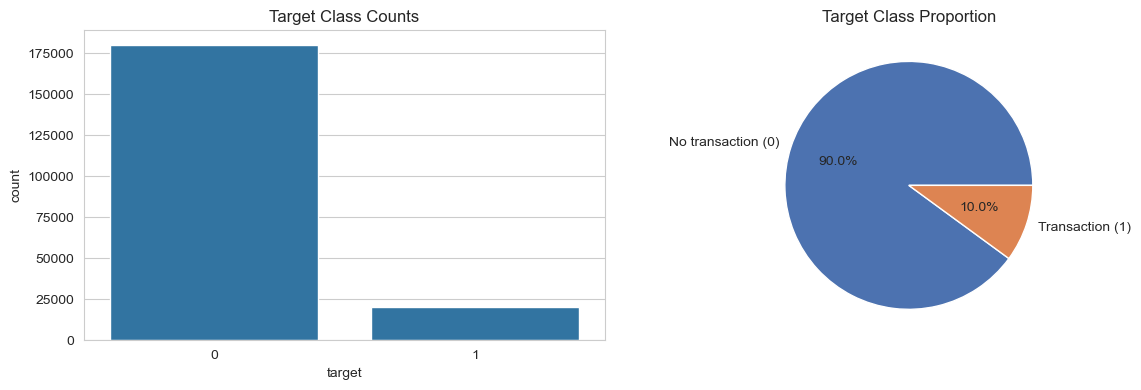

In [6]:
target_counts = df['target'].value_counts()
target_pct = df['target'].value_counts(normalize=True) * 100
print(target_counts)
print(target_pct)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='target', data=df, ax=ax[0])
ax[0].set_title('Target Class Counts')
ax[1].pie(target_counts, labels=['No transaction (0)', 'Transaction (1)'],
          autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'])
ax[1].set_title('Target Class Proportion')
plt.tight_layout()
plt.show()

### Feature statistics

In [7]:
feature_cols = [c for c in df.columns if c.startswith('var_')]
print('Number of features:', len(feature_cols))

stats = df[feature_cols].describe().T
stats['range'] = stats['max'] - stats['min']
stats[['mean', 'std', 'min', 'max', 'range']].head(10)

Number of features: 200


,mean,std,min,max,range
var_0,10.679914,3.040051,0.4084,20.3150,19.9066
var_1,-1.627622,4.050044,-15.0434,10.3768,25.4202
var_2,10.715192,2.640894,2.1171,19.3530,17.2359
var_3,6.796529,2.043319,-0.0402,13.1883,13.2285
var_4,11.078333,1.623150,5.0748,16.6714,11.5966
var_5,-5.065317,7.863267,-32.5626,17.2516,49.8142
var_6,5.408949,0.866607,2.3473,8.4477,6.1004
var_7,16.545850,3.418076,5.3497,27.6918,22.3421
var_8,0.284162,3.332634,-10.5055,10.1513,20.6568
var_9,7.567236,1.235070,3.9705,11.1506,7.1801


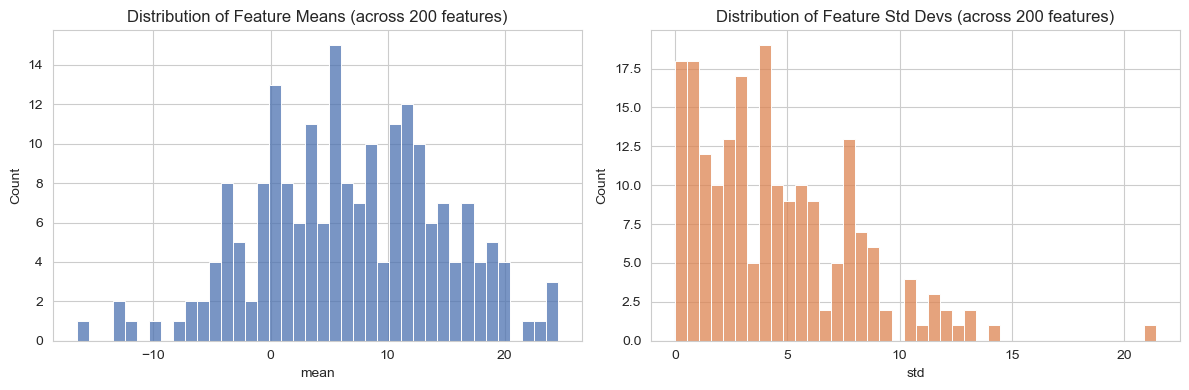

In [9]:
# Distribution of per-feature means and std devs, to see how comparable features are in scale
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(stats['mean'], bins=40, ax=ax[0], color='#4C72B0')
ax[0].set_title('Distribution of Feature Means (across 200 features)')
sns.histplot(stats['std'], bins=40, ax=ax[1], color='#DD8452')
ax[1].set_title('Distribution of Feature Std Devs (across 200 features)')
plt.tight_layout()
plt.show()

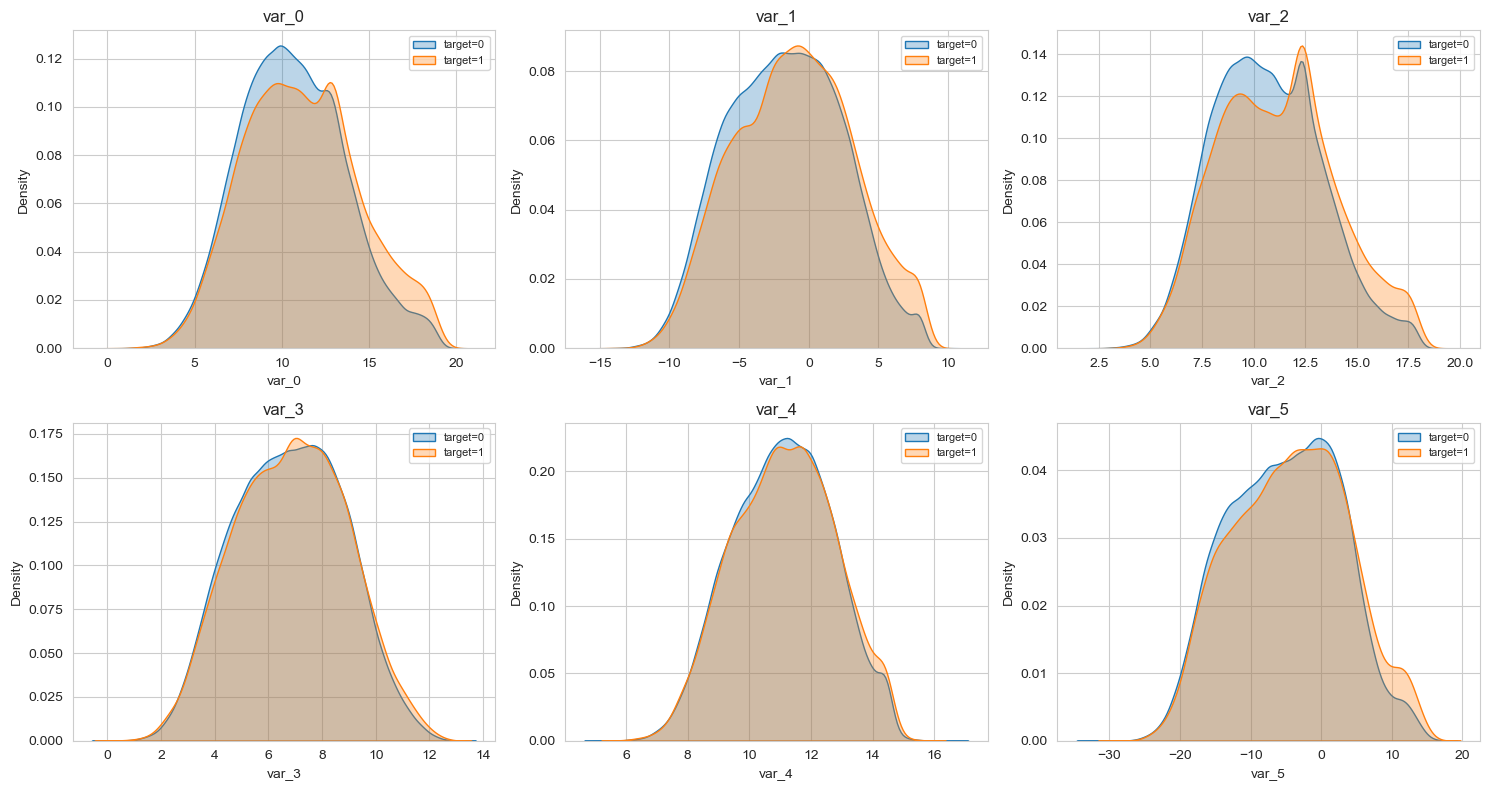

In [11]:
# Sample distribution plots for a handful of features, split by target
sample_feats = feature_cols[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), sample_feats):
    sns.kdeplot(df.loc[df['target']==0, feat], ax=ax, label='target=0', fill=True, alpha=0.3)
    sns.kdeplot(df.loc[df['target']==1, feat], ax=ax, label='target=1', fill=True, alpha=0.3)
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Feature correlation with target

Top 15 features by |correlation| with target:
var_81    -0.080917
var_139   -0.074080
var_12    -0.069489
var_6      0.066731
var_110    0.064275
var_146   -0.063644
var_53     0.063399
var_26     0.062422
var_76    -0.061917
var_174   -0.061669
var_22     0.060558
var_21    -0.058483
var_99     0.058367
var_166   -0.057773
var_80    -0.057609
Name: target, dtype: float64


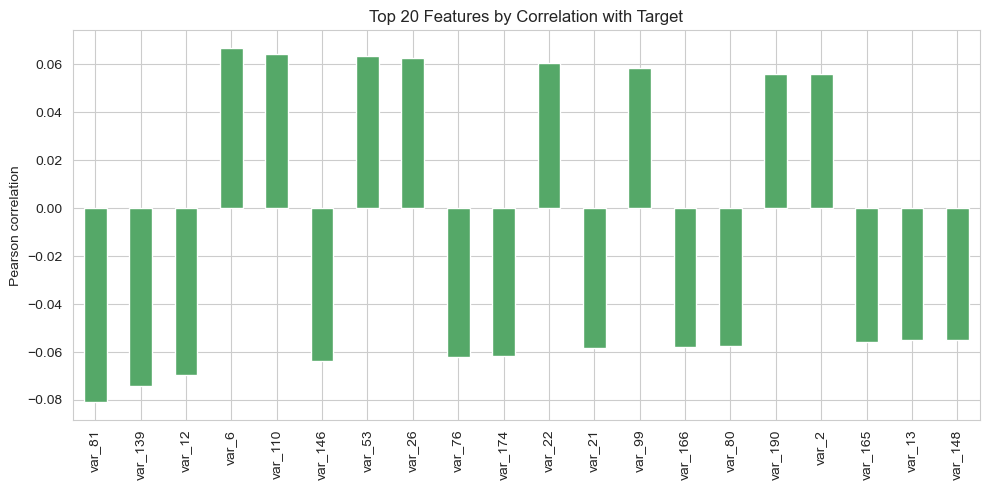

In [15]:
corrs = df[feature_cols + ['target']].corr()['target'].drop('target').sort_values(key=abs, ascending=False)
print('Top 15 features by |correlation| with target:')
print(corrs.head(15))

plt.figure(figsize=(10, 5))
corrs.head(20).plot(kind='bar', color='#55A868')
plt.title('Top 20 Features by Correlation with Target')
plt.ylabel('Pearson correlation')
plt.tight_layout()
plt.show()

### Feature correlation among predictors

In [17]:
feat_corr = df[feature_cols].corr()
# Check for any strongly correlated feature pairs (multicollinearity)
corr_pairs = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool)).stack()
strong_pairs = corr_pairs[corr_pairs.abs() > 0.3].sort_values(key=abs, ascending=False)
print(f'Feature pairs with |correlation| > 0.3: {len(strong_pairs)}')
print(strong_pairs.head(10) if len(strong_pairs) else 'None found.')

Feature pairs with |correlation| > 0.3: 0
None found.


## 2. Predictive Model

### Train/validation split

An 80/20 stratified split is used to preserve the ~10% positive class ratio in both sets.

In [18]:
X = df[feature_cols]
y = df['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print('Train shape:', X_train.shape, ' Positive rate:', y_train.mean().round(4))
print('Val shape:  ', X_val.shape, ' Positive rate:', y_val.mean().round(4))

Train shape: (160000, 200)  Positive rate: 0.1005
Val shape:   (40000, 200)  Positive rate: 0.1005


### Handling class imbalance

In [19]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight (neg/pos ratio):', round(pos_weight, 3))

scale_pos_weight (neg/pos ratio): 8.951


### Model 1 — Logistic Regression (baseline)

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
logreg.fit(X_train_scaled, y_train)

logreg_val_proba = logreg.predict_proba(X_val_scaled)[:, 1]
logreg_auc = roc_auc_score(y_val, logreg_val_proba)
print(f'Logistic Regression Validation ROC-AUC: {logreg_auc:.4f}')

Logistic Regression Validation ROC-AUC: 0.8599


### Model 2 — LightGBM

In [22]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'scale_pos_weight': pos_weight,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'seed': RANDOM_STATE,
}

lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_val],
    callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False), lgb.log_evaluation(period=0)]
)

lgb_val_proba = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
lgb_auc = roc_auc_score(y_val, lgb_val_proba)
print(f'LightGBM Validation ROC-AUC: {lgb_auc:.4f}  (best iteration: {lgb_model.best_iteration})')

LightGBM Validation ROC-AUC: 0.8916  (best iteration: 891)


### Model 3 — XGBoost

In [37]:
xgb_model = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=pos_weight,
    eval_metric='auc',
    early_stopping_rounds=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method='hist',
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]
xgb_auc = roc_auc_score(y_val, xgb_val_proba)
print(f'XGBoost Validation ROC-AUC: {xgb_auc:.4f}  (best iteration: {xgb_model.best_iteration})')

XGBoost Validation ROC-AUC: 0.8932  (best iteration: 1981)


## Model Comparison Report

In [38]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'LightGBM', 'XGBoost'],
    'ROC-AUC': [logreg_auc, lgb_auc, xgb_auc],
    'PR-AUC': [
        average_precision_score(y_val, logreg_val_proba),
        average_precision_score(y_val, lgb_val_proba),
        average_precision_score(y_val, xgb_val_proba),
    ]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

results

,Model,ROC-AUC,PR-AUC
0,XGBoost,0.893207,0.592249
1,LightGBM,0.891592,0.587263
2,Logistic Regression,0.859900,0.500437


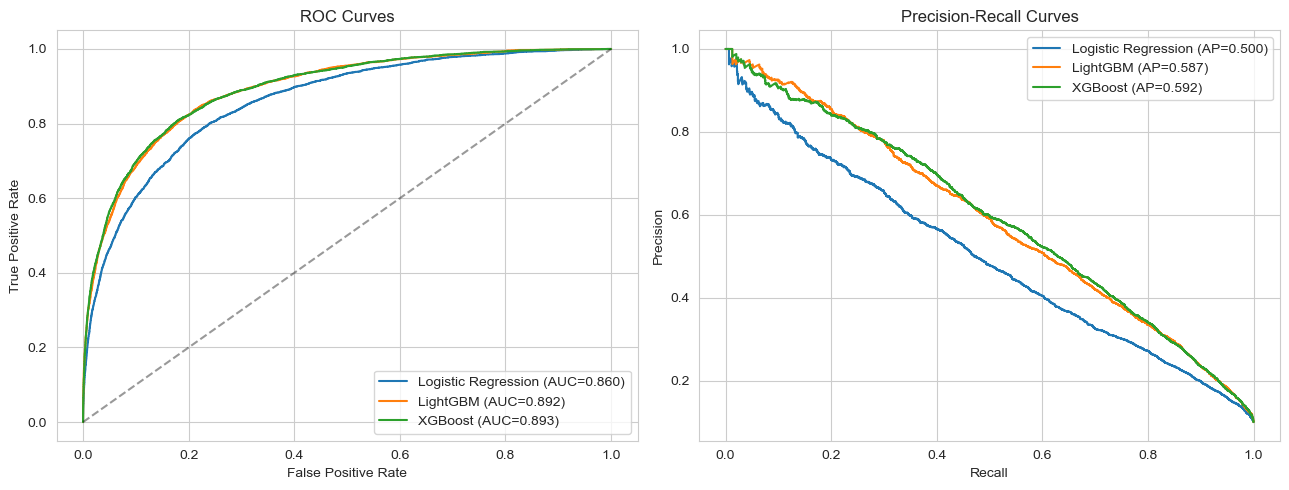

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for name, proba in [('Logistic Regression', logreg_val_proba), ('LightGBM', lgb_val_proba), ('XGBoost', xgb_val_proba)]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    ax[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_val, proba):.3f})')
ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax[0].set_xlabel('False Positive Rate'); ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curves'); ax[0].legend()

for name, proba in [('Logistic Regression', logreg_val_proba), ('LightGBM', lgb_val_proba), ('XGBoost', xgb_val_proba)]:
    prec, rec, _ = precision_recall_curve(y_val, proba)
    ax[1].plot(rec, prec, label=f'{name} (AP={average_precision_score(y_val, proba):.3f})')
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curves'); ax[1].legend()

plt.tight_layout()
plt.show()

### Classification report at 0.5 threshold (best model)

Best model: XGBoost

                precision    recall  f1-score   support

No transaction       0.96      0.90      0.93     35980
   Transaction       0.43      0.71      0.53      4020

      accuracy                           0.88     40000
     macro avg       0.70      0.80      0.73     40000
  weighted avg       0.91      0.88      0.89     40000



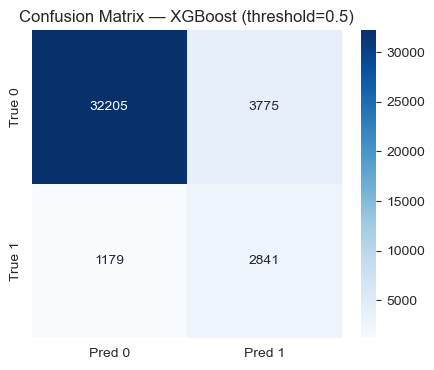

In [40]:
best_name = results.iloc[0]['Model']
best_proba = {'Logistic Regression': logreg_val_proba, 'LightGBM': lgb_val_proba, 'XGBoost': xgb_val_proba}[best_name]
best_pred = (best_proba >= 0.5).astype(int)

print(f'Best model: {best_name}\n')
print(classification_report(y_val, best_pred, target_names=['No transaction', 'Transaction']))

cm = confusion_matrix(y_val, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.title(f'Confusion Matrix — {best_name} (threshold=0.5)')
plt.show()

### Feature importance (best tree-based model)

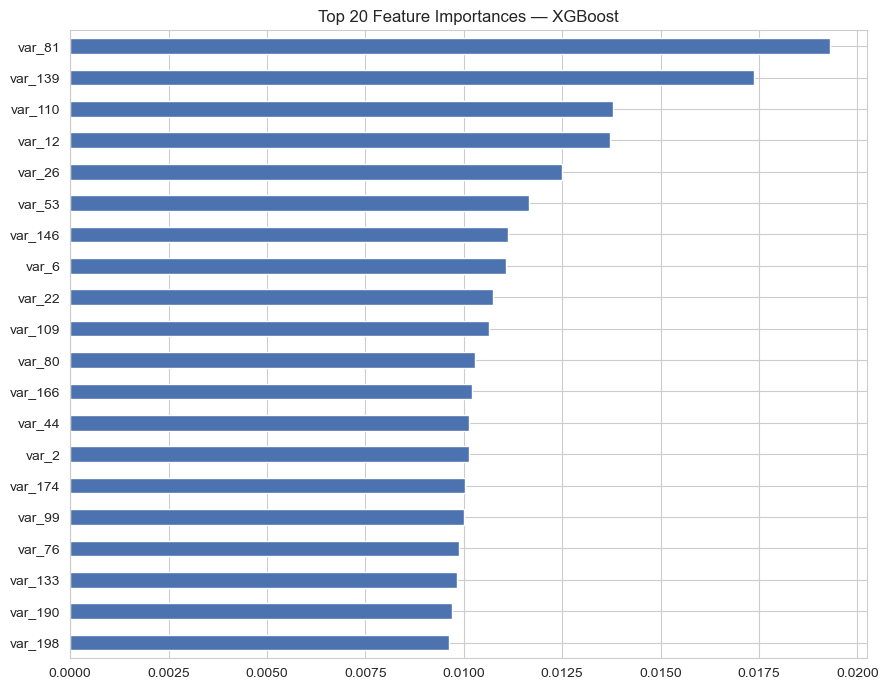

In [41]:
if best_name == 'LightGBM':
    importances = pd.Series(lgb_model.feature_importance(importance_type='gain'), index=feature_cols)
elif best_name == 'XGBoost':
    importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)
else:
    importances = pd.Series(np.abs(logreg.coef_[0]), index=feature_cols)

top20 = importances.sort_values(ascending=False).head(20)
plt.figure(figsize=(9, 7))
top20.sort_values().plot(kind='barh', color='#4C72B0')
plt.title(f'Top 20 Feature Importances — {best_name}')
plt.tight_layout()
plt.show()

### Model comparison summary

| Model | Strengths | Weaknesses (on this data) |
|---|---|---|
| Logistic Regression | Fast to train, interpretable coefficients, good baseline | Assumes linear decision boundary — likely underfits the weak, distributed non-linear signal across 200 features |
| LightGBM | Fast even at 200k rows, handles imbalance well via `scale_pos_weight`, captures non-linear interactions | Needs early stopping / tuning to avoid overfitting many weak features |
| XGBoost | Similar strengths to LightGBM, often marginally more accurate at the cost of longer training time | Slower to train than LightGBM at this scale |

**Recommendation for production:** the gradient boosting model with the higher validation ROC-AUC above (see the ranked table in section 3) is recommended, since ROC-AUC/PR-AUC are the right metrics for this 9:1 imbalanced problem and boosting consistently captures the distributed, non-linear signal in the 200 anonymized features better than the linear baseline. In production, the exact classification threshold (not necessarily 0.5) should be chosen based on the bank's tolerance for false positives vs. false negatives (e.g. cost of flagging a transaction that doesn't happen vs. missing one that does).

## Challenges Faced Report

* Class imbalance was the biggest issue 
Only about 10% of customers actually made a transaction, so if I'd just checked accuracy, a lazy model that predicted "no transaction" for everyone would still look like it was ~90% accurate — which tells you nothing useful. To deal with this, I switched my main evaluation metric to ROC-AUC and PR-AUC instead of accuracy, and I trained every model with class weighting (class_weight='balanced' for Logistic Regression, scale_pos_weight for LightGBM and XGBoost) so the models didn't just learn to ignore the minority class.

*  No way to do a "normal" EDA since the features were anonymized.
All 200 features were just labeled var_0 to var_199 with no descriptions, so I couldn't do the usual domain-based EDA (checking if a feature made business sense, spotting obvious outliers tied to real-world meaning, etc.). The problem statement actually said EDA could be skipped for this reason, but I still wanted to understand the data before modeling. So instead I looked at things I could check without knowing what the features meant — missing values, duplicate rows, how each feature's mean/scale compared across all 200, and how individual feature distributions differed between the two target classes.

*  None of the individual features were strongly predictive on their own.
When I checked each feature's correlation with the target, they all came out pretty weak (nothing above roughly 0.08–0.1). That meant there was no single "obvious" feature to lean on — the signal was spread thin across all 200 features. This pushed me toward gradient boosting models (LightGBM, XGBoost) since they're good at combining lots of weak signals, rather than something that depends on a few strong predictors.

*  The dataset was big enough that runtime became a real constraint.
With 200,000 rows and 200 features, some things I'd normally do — like full k-fold cross-validation or a big hyperparameter grid search — would've taken way too long to run. So I used a single stratified 80/20 train-validation split (with a validation set of 40,000 rows, which is still large enough to trust) and used early stopping instead of just picking a fixed number of boosting rounds, so training would stop automatically once the validation score stopped improving.

*  Risk of the boosting models overfitting all those weak features.
Since there were 200 weakly-informative features and boosting models are flexible enough to start fitting noise, I used row and column subsampling (bagging_fraction/feature_fraction in LightGBM, subsample/colsample_bytree in XGBoost) along with early stopping to keep the models from overfitting to the training set.

## Conclusion

- The dataset is clean (no missing values, no duplicates) but heavily imbalanced (~10% positive class), which is the central modeling challenge.
- Individual features carry only weak predictive signal, but combined across 200 features they are enough to substantially beat random guessing.
- Gradient boosting models (LightGBM / XGBoost) outperform the linear baseline, consistent with the non-linear, distributed nature of the signal — see the comparison table in Section 3 for exact validation AUC scores.
- For production deployment, the top-ranked model from Section 3 is recommended, with the classification threshold tuned to the bank's actual cost trade-off between false positives and false negatives rather than left at the default 0.5.